# Chapter 1 — Introduction

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain what machine learning is and why it is useful.
2. Distinguish between supervised and unsupervised learning at a basic level.
3. Understand the role of Python and common scientific libraries in machine learning.
4. Load and inspect the Iris dataset using `scikit-learn`.
5. Build, evaluate, and interpret a first machine learning model using k-Nearest Neighbors.

## Chapter Overview

Machine learning is about extracting useful patterns from data. Instead of manually writing every decision rule, we provide examples to an algorithm and allow it to learn patterns from those examples.

Chapter 1 introduces the practical workflow used throughout the book: loading data, understanding features and labels, splitting data into training and test sets, building a model, making predictions, and evaluating performance.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Essential Python Libraries

The book uses the scientific Python ecosystem. The most important libraries are:

- **NumPy:** numerical arrays and mathematical operations.
- **pandas:** table-like data handling through DataFrames.
- **matplotlib:** visualization.
- **scikit-learn:** machine learning algorithms and utilities.

### What this code does

This cell imports the main libraries and prints their versions where available. Version checking is useful because code behavior can change across library versions.

In [2]:
import sklearn
import scipy

print('NumPy version:', np.__version__)
print('pandas version:', pd.__version__)
print('scikit-learn version:', sklearn.__version__)
print('SciPy version:', scipy.__version__)

NumPy version: 1.26.4
pandas version: 2.2.2
scikit-learn version: 1.5.1
SciPy version: 1.13.1


### Output Interpretation

The output confirms that the required libraries are installed. If a package is missing, the notebook cannot run correctly. In real projects, these versions should be documented in `requirements.txt` to make experiments reproducible.

## 2. Loading the Iris Dataset

The Iris dataset is a classic dataset in machine learning. It contains measurements of iris flowers and their species labels.

### Theory

Each row is a **sample**. Each column in the data matrix is a **feature**. The target value is the **label** that the supervised learning algorithm tries to predict.

The task is a **multiclass classification problem** because the model predicts one of three possible species.

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

print('Dataset keys:', iris.keys())
print('Target names:', iris.target_names)
print('Feature names:', iris.feature_names)
print('Data shape:', iris.data.shape)
print('Target shape:', iris.target.shape)
print('\nFirst five samples:')
print(iris.data[:5])
print('\nFirst five target values:', iris.target[:5])

Dataset keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Target names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Data shape: (150, 4)
Target shape: (150,)

First five samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First five target values: [0 0 0 0 0]


### Output Interpretation

The dataset contains 150 samples and 4 numerical features. The target values are encoded as integers, where each integer corresponds to one iris species. The feature names describe sepal and petal measurements in centimeters.

## 3. Creating a DataFrame for Inspection

Before training a model, it is important to inspect the data. A DataFrame makes the data easier to read and helps verify that the features are numeric and structured correctly.

In [4]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['species'] = iris_df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print(iris_df.head())
print('\nClass distribution:')
print(iris_df['species'].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Output Interpretation

The class distribution is balanced: each species has the same number of samples. This makes accuracy easier to interpret because no class dominates the dataset.

## 4. Visual Exploration

A simple scatter plot can reveal whether classes are separable using two features. Here we plot petal length and petal width because these features often separate iris species clearly.

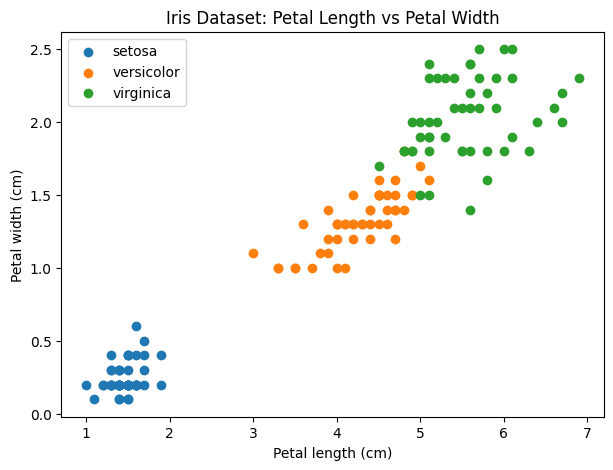

In [5]:
plt.figure(figsize=(7, 5))
for target_value, target_name in enumerate(iris.target_names):
    subset = iris_df[iris_df['target'] == target_value]
    plt.scatter(
        subset['petal length (cm)'],
        subset['petal width (cm)'],
        label=target_name
    )
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Iris Dataset: Petal Length vs Petal Width')
plt.legend()
plt.show()

### Output Interpretation

The plot shows that the species are not randomly mixed. Some species are clearly separated based on petal measurements. This suggests that a machine learning classifier should be able to learn useful decision patterns.

## 5. Train-Test Split

We split the data into training and test sets. The model learns only from the training set. The test set is used later to estimate how well the model generalizes to unseen flowers.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    random_state=RANDOM_STATE
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (112, 4)
X_test shape : (38, 4)
y_train shape: (112,)
y_test shape : (38,)


### Output Interpretation

The training set contains most of the samples, while the test set is held out for evaluation. This separation prevents the model from being evaluated only on examples it has already seen.

## 6. Building the First Model: k-Nearest Neighbors

k-Nearest Neighbors is a simple supervised learning algorithm. It stores the training data and predicts a new sample based on the labels of nearby training samples.

Here we use `n_neighbors=1`, meaning the prediction is based on the single closest training example.

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print('Model training completed.')
print('Training accuracy:', round(knn.score(X_train, y_train), 4))
print('Test accuracy:', round(knn.score(X_test, y_test), 4))

Model training completed.
Training accuracy: 1.0
Test accuracy: 1.0


### Output Interpretation

Training accuracy shows how well the model fits the training data. Test accuracy is more important because it estimates performance on unseen data. If training accuracy is much higher than test accuracy, that may indicate overfitting.

## 7. Making a Prediction

After the model is trained, it can predict the species of a new iris flower from its measurements.

In [8]:
X_new = np.array([[5.0, 2.9, 1.0, 0.2]])
prediction = knn.predict(X_new)

print('New sample:', X_new)
print('Predicted class index:', prediction[0])
print('Predicted species:', iris.target_names[prediction][0])

New sample: [[5.  2.9 1.  0.2]]
Predicted class index: 0
Predicted species: setosa


### Output Interpretation

The model returns a class index, which is mapped back to the species name using `iris.target_names`. This demonstrates how a trained model can be used for prediction on new data.

## Key Takeaways

- Machine learning learns patterns from data instead of relying only on manually written rules.
- The Iris example is a supervised multiclass classification problem.
- Data is represented as `X` for features and `y` for labels.
- Train-test split is necessary to estimate generalization performance.
- k-NN is simple but useful as a first model and baseline.

## Chapter Summary

Chapter 1 introduces the complete basic workflow of machine learning in Python: load data, inspect it, split it, train a model, make predictions, and evaluate the result. This workflow becomes the foundation for the more advanced chapters.